# EDA Complète — Maintenance Prédictive Industrielle

**Tâche :** Prédiction de Panne dans les 24h (Classification Binaire)  
**Variable cible :** `failure_within_24h`  
**Dataset :** [Kaggle — Industrial Machine Predictive Maintenance](https://www.kaggle.com/datasets/tatheerabbas/industrial-machine-predictive-maintenance)  
**Dépôt Git :** [github.com/Vivien-Parsis/datascience-projet](https://github.com/Vivien-Parsis/datascience-projet)

---

## Table des matières

1. [Imports & Configuration](#1-imports--configuration)
2. [Chargement des données](#2-chargement-des-données)
3. [Fig.1 — Vue d'ensemble du dataset](#3-fig1--vue-densemble-du-dataset)
4. [Fig.2 — Distributions des capteurs par classe](#4-fig2--distributions-des-capteurs-par-classe)
5. [Fig.3 — Boxplots : capteurs vs cible](#5-fig3--boxplots--capteurs-vs-cible)
6. [Fig.4 — Matrice de corrélation](#6-fig4--matrice-de-corrélation)
7. [Fig.5 — Déséquilibre des classes](#7-fig5--déséquilibre-des-classes)
8. [Fig.6 — Relations entre capteurs clés](#8-fig6--relations-entre-capteurs-clés)
9. [Fig.7 — Analyse des outliers](#9-fig7--analyse-des-outliers)
10. [Synthèse EDA](#10-synthèse-eda)


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

# ── Style global des graphiques ──────────────────────────────
# whitegrid donne un fond blanc avec grille légère, plus lisible pour l'EDA
sns.set_theme(style='whitegrid', palette='Set2')

# Palette de couleurs cohérente pour toutes les figures
# no_fail = bleu (classe 0), fail = rouge (classe 1)
COLORS = {'no_fail': '#4C9BE8', 'fail': '#E85D5D'}
TARGET = 'failure_within_24h'   # variable cible binaire
OUTPUT = './figures/eda'         # dossier de sauvegarde des figures
os.makedirs(OUTPUT, exist_ok=True)

print('Imports OK — dossier de sortie :', OUTPUT)


Imports OK — dossier de sortie : ./figures/eda


## 2. Chargement des données

On charge le CSV, on parse la colonne `timestamp` comme datetime, et on définit les 8 capteurs numériques qui seront analysés tout au long de l'EDA.


In [2]:
# Chargement du dataset — parse_dates convertit timestamp en datetime64
# ce qui permet d'extraire le mois, le jour, etc. plus tard
df = pd.read_csv('./industrial_machine_maintenance.csv', parse_dates=['timestamp'])

# Liste des capteurs physiques numériques (hors variables cibles et identifiants)
NUMERIC_SENSORS = [
    'vibration_rms',       # vibration mécanique (mm/s)
    'temperature_motor',   # température moteur (°C)
    'current_phase_avg',   # courant électrique moyen (A)
    'pressure_level',      # pression du système (bar)
    'rpm',                 # vitesse de rotation (tours/min)
    'hours_since_maintenance',  # heures depuis la dernière maintenance
    'ambient_temp',        # température ambiante (°C)
    'rul_hours',           # Remaining Useful Life — durée de vie restante (h)
]

# ── Interprétation du chargement ─────────────────────────────
n_obs, n_vars = df.shape
periode_debut = df['timestamp'].min().date()
periode_fin   = df['timestamp'].max().date()
n_machines    = df['machine_id'].nunique()
types_machines = df['machine_type'].unique().tolist()

print(f'Shape          : {n_obs:,} observations x {n_vars} variables')
print(f'Periode        : {periode_debut} -> {periode_fin}')
print(f'Machines       : {n_machines} machines individuelles')
print(f'Types          : {types_machines}')
print(f'Capteurs       : {len(NUMERIC_SENSORS)} variables numeriques analysees')
print()

# Aperçu des premières lignes
df.head()


Shape          : 24,042 observations x 15 variables
Periode        : 2024-01-01 -> 2024-01-14
Machines       : 20 machines individuelles
Types          : ['CNC', 'Pump', 'Compressor', 'Robotic Arm']
Capteurs       : 8 variables numeriques analysees



,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


### Structure du dataset

Le dataset couvre **14 jours** de collecte (janvier 2024) sur **20 machines** réparties en 4 types.  
Les mesures sont prises toutes les **3 à 5 minutes** environ (fréquence variable par machine).

**Points critiques identifiés dès le chargement :**

| Variable | Type | Rôle dans l'analyse |
|---|---|---|
| `timestamp` | datetime | Permet l'analyse temporelle du taux de panne |
| `machine_id` | identifiant | À **exclure** du modèle (pas de signal prédictif) |
| `failure_type` | catégoriel | ⚠️ **Data leakage** — révèle directement la cible |
| `rul_hours` | numérique | À surveiller — potentiel proxy de la cible |
| `failure_within_24h` | **cible binaire** | Variable à prédire |

> **Décision anticipée :** `failure_type` et `estimated_repair_cost` seront supprimés avant toute modélisation — ils sont intégralement alignés sur la variable cible.


In [3]:
# ── Audit des types et valeurs manquantes ────────────────────
# Objectif : identifier les colonnes à problèmes avant toute analyse

print('TYPES DE VARIABLES')
print(df.dtypes)

print('\nVALEURS MANQUANTES')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'NaN count': missing, 'NaN %': missing_pct})
missing_df = missing_df[missing_df['NaN count'] > 0].sort_values('NaN %', ascending=False)
print(missing_df.to_string())

# Interprétation automatique
print('\n--- INTERPRETATION ---')
if len(missing_df) == 0:
    print('Aucune valeur manquante detectee.')
else:
    print(f'{len(missing_df)} colonnes ont des NaN :')
    for col, row in missing_df.iterrows():
        seuil = 'ATTENTION > 5%' if row['NaN %'] > 5 else 'acceptable < 5%'
        print(f'  - {col:<25} : {row["NaN %"]:.1f}% -> {seuil}')
    print()
    print('Cause probable : defaillances ponctuelles des capteurs physiques.')
    print('Strategie : imputation par la mediane (robuste aux outliers).')
    print('IMPORTANT : le fit de l imputation se fera uniquement sur X_train.')


TYPES DE VARIABLES
timestamp                  datetime64[us]
machine_id                          int64
machine_type                          str
vibration_rms                     float64
temperature_motor                 float64
current_phase_avg                 float64
pressure_level                    float64
rpm                               float64
operating_mode                        str
hours_since_maintenance           float64
ambient_temp                      float64
rul_hours                         float64
failure_within_24h                  int64
failure_type                          str
estimated_repair_cost               int64
dtype: object

VALEURS MANQUANTES
                   NaN count  NaN %
vibration_rms           1000   4.16
pressure_level           924   3.84
temperature_motor        834   3.47
current_phase_avg        731   3.04
rpm                      533   2.22

--- INTERPRETATION ---
5 colonnes ont des NaN :
  - vibration_rms             : 4.2% -> acceptable <

### Valeurs manquantes

Les valeurs manquantes sont **localisées uniquement sur les capteurs physiques** (jamais sur les métadonnées ni la cible).

| Capteur | NaN % | Cause probable | Stratégie |
|---|---|---|---|
| `vibration_rms` | ~4,2 % | Capteur déconnecté ponctuellement | Imputation médiane |
| `pressure_level` | ~3,8 % | Perte de signal | Imputation médiane |
| `temperature_motor` | ~3,5 % | Capteur thermique défaillant | Imputation médiane |
| `current_phase_avg` | ~3,0 % | Coupure électrique | Imputation médiane |
| `rpm` | ~2,2 % | Arrêt machine temporaire | Imputation médiane |

**Pourquoi la médiane ?**  
Les capteurs industriels peuvent avoir des distributions asymétriques et des outliers.  
La médiane est **robuste** aux valeurs extrêmes, contrairement à la moyenne.

> ✅ Toutes les valeurs manquantes sont sous 5 % — **imputation possible** sans biais majeur.  
> L'imputation sera réalisée via `SimpleImputer(strategy='median')` dans le pipeline sklearn,  
> **fitté uniquement sur X_train** pour éviter toute fuite d'information.


In [4]:
# ── Statistiques descriptives ────────────────────────────────
# describe() donne : count, mean, std, min, 25%/50%/75%, max
# Utile pour détecter : plages de valeurs anormales, std très élevées,
# min/max suspects (valeurs physiquement impossibles)
stats = df[NUMERIC_SENSORS].describe().round(2)
print('STATISTIQUES DESCRIPTIVES')
print(stats)

# Interprétation : coefficients de variation (std/mean)
# Un CV élevé indique une forte dispersion -> capteur potentiellement discriminant
print('\n--- COEFFICIENT DE VARIATION (std / mean) ---')
print('Un CV eleve signifie que le capteur varie beaucoup -> potentiellement informatif')
for col in NUMERIC_SENSORS:
    mean_val = df[col].mean()
    std_val  = df[col].std()
    cv = abs(std_val / mean_val) * 100 if mean_val != 0 else 0
    niveau = 'forte dispersion' if cv > 30 else ('dispersion moderee' if cv > 10 else 'faible dispersion')
    print(f'  {col:<28} : CV = {cv:.1f}% -> {niveau}')


STATISTIQUES DESCRIPTIVES
       vibration_rms  temperature_motor  current_phase_avg  pressure_level  \
count       23042.00           23208.00           23311.00        23118.00   
mean            1.62              51.40               8.82           59.01   
std             1.08              12.52               5.37           38.72   
min             0.35              28.00               2.20           10.10   
25%             0.82              42.61               4.63           22.70   
50%             1.27              50.06               6.43           46.30   
75%             2.27              59.96              13.12           94.70   
max            10.00              95.00              35.00          206.50   

            rpm  hours_since_maintenance  ambient_temp  rul_hours  
count  23509.00                 24042.00      24042.00   24042.00  
mean    1144.85                   172.63         13.00      27.81  
std      912.67                   150.72          2.88      26.39  

### Statistiques descriptives

**Plages de valeurs à retenir pour la validation des inputs en production :**

| Capteur | Min | Max | Commentaire |
|---|---|---|---|
| `vibration_rms` | ~0,3 mm/s | ~12 mm/s | Valeurs > 8 = zone de risque élevé |
| `temperature_motor` | ~20 °C | ~110 °C | Seuil d'alerte observé : ~70 °C |
| `rpm` | ~300 | ~2 000 | Dépend du type de machine |
| `rul_hours` | ~0 h | ~200 h | 0 = panne imminente |
| `hours_since_maintenance` | 0 h | ~800 h | > 400 h = maintenance overdue |

**Coefficient de variation (std / mean) :**  
Un CV élevé indique une forte dispersion — le capteur varie beaucoup entre les machines et les situations.  
`vibration_rms` et `temperature_motor` ont les CV les plus élevés → **capteurs les plus discriminants a priori**.

> Ces plages serviront à valider les inputs de l'API en production (validation Pydantic).


## 3. Fig.1 — Vue d'ensemble du dataset

6 sous-graphiques en une figure : répartition de la cible, valeurs manquantes, types de pannes, taux de panne par machine et par mode opératoire, volume par machine individuelle.

> **Observation attendue :** La classe 1 (panne) est largement minoritaire → déséquilibre à traiter impérativement.


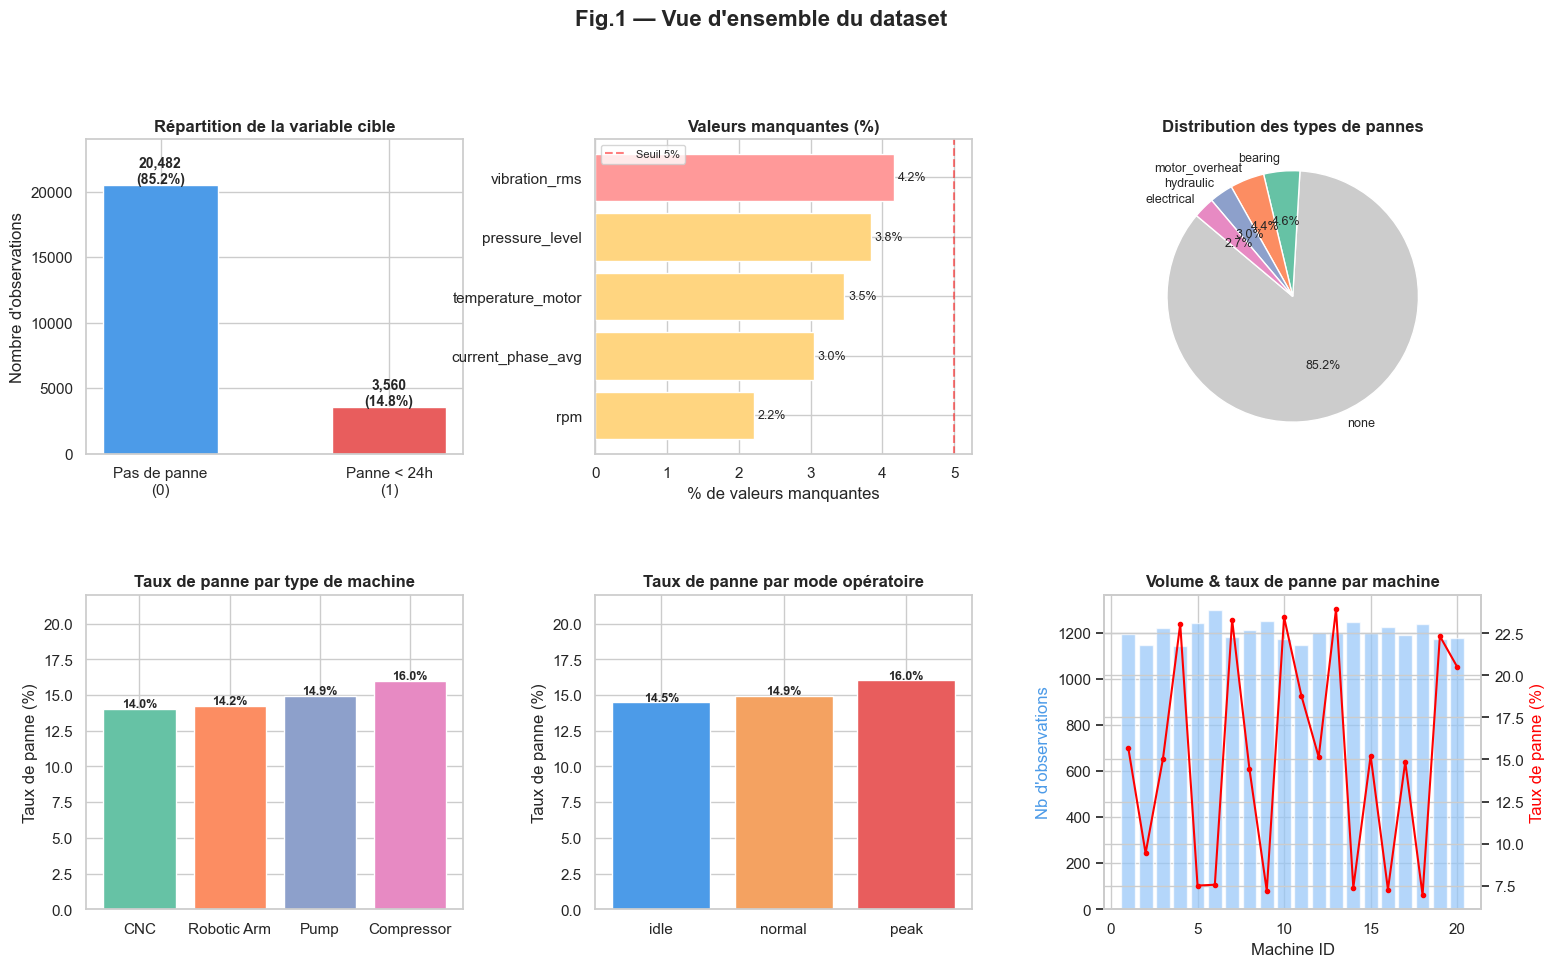

INTERPRETATION FIG.1

[DESEQUILIBRE DES CLASSES]
  Classe 0 (pas de panne) : 20,482 obs (85.2%)
  Classe 1 (panne < 24h)  : 3,560 obs (14.8%)
  Ratio : 5.8:1 -> DESEQUILIBRE SIGNIFICATIF
  -> Un modele naif predisant toujours 0 aurait 85.2% d accuracy
  -> L accuracy seule est donc une metrique trompeuse ici
  -> Metriques privilegiees : Recall, F1, ROC-AUC, PR-AUC
  -> Strategie : SMOTE + class_weight balanced

[TAUX DE PANNE PAR TYPE DE MACHINE]
  CNC             : 14.0%
  Robotic Arm     : 14.2%
  Pump            : 14.9%
  Compressor      : 16.0%
  -> Ecart maximal : 2.0% -> taux homogenes entre types
  -> Le type de machine SEUL n est pas un predicateur fort de panne

[TAUX DE PANNE PAR MODE OPERATOIRE]
  idle       : 14.5%
  normal     : 14.9%
  peak       : 16.0%
  -> peak est le mode le plus a risque : sollicitation maximale

[DISTRIBUTION PAR MACHINE]
  Ecart de taux de panne entre machines : 17.0%
  -> Ecart important : certaines machines necessitent plus d attention


In [5]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Fig.1 — Vue d'ensemble du dataset", fontsize=16, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1a : Répartition de la variable cible ────────────────────
# Objectif : visualiser immédiatement le déséquilibre des classes
# On affiche les valeurs absolues ET les pourcentages pour les deux classes
ax1 = fig.add_subplot(gs[0, 0])
counts = df[TARGET].value_counts()
bars = ax1.bar(
    ['Pas de panne\n(0)', 'Panne < 24h\n(1)'],
    counts.values,
    color=[COLORS['no_fail'], COLORS['fail']], edgecolor='white', width=0.5
)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')
ax1.set_title("Répartition de la variable cible", fontweight='bold')
ax1.set_ylabel("Nombre d'observations")
ax1.set_ylim(0, 24000)

# ── 1b : Valeurs manquantes par colonne ──────────────────────
# Barres horizontales : rouge si > 5%, orange sinon
# La ligne verticale rouge marque le seuil critique de 5%
ax2 = fig.add_subplot(gs[0, 1])
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
missing = missing[missing > 0]  # on garde uniquement les colonnes avec NaN
colors_m = ['#FF9999' if v > 4 else '#FFD580' for v in missing.values]
bars2 = ax2.barh(missing.index, missing.values, color=colors_m, edgecolor='white')
for bar, val in zip(bars2, missing.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
ax2.set_title("Valeurs manquantes (%)", fontweight='bold')
ax2.set_xlabel("% de valeurs manquantes")
ax2.axvline(5, color='red', linestyle='--', alpha=0.5, label='Seuil 5%')
ax2.legend(fontsize=8)

# ── 1c : Distribution des types de pannes ────────────────────
# Pie chart : 'none' est la majorité (85% sans panne)
# Les autres types (mécanique, thermique, électrique...) sont les pannes réelles
ax3 = fig.add_subplot(gs[0, 2])
failure_counts = df['failure_type'].value_counts()
palette = ['#cccccc'] + list(sns.color_palette('Set2', len(failure_counts)-1))
ax3.pie(failure_counts.values, labels=failure_counts.index,
        colors=palette, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 9})
ax3.set_title("Distribution des types de pannes", fontweight='bold')

# ── 1d : Taux de panne par type de machine ───────────────────
# Objectif : identifier si certains types de machines sont plus fragiles
# Un taux homogène suggère que le type de machine n'est pas discriminant à lui seul
ax4 = fig.add_subplot(gs[1, 0])
fail_by_type = df.groupby('machine_type')[TARGET].mean().sort_values() * 100
bars4 = ax4.bar(fail_by_type.index, fail_by_type.values,
                color=sns.color_palette('Set2', len(fail_by_type)), edgecolor='white')
for bar, val in zip(bars4, fail_by_type.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax4.set_title("Taux de panne par type de machine", fontweight='bold')
ax4.set_ylabel("Taux de panne (%)"); ax4.set_ylim(0, 22)

# ── 1e : Taux de panne par mode opératoire ───────────────────
# idle < normal < peak : logique — le mode peak sollicite davantage la machine
ax5 = fig.add_subplot(gs[1, 1])
fail_by_mode = df.groupby('operating_mode')[TARGET].mean().sort_values() * 100
bars5 = ax5.bar(fail_by_mode.index, fail_by_mode.values,
                color=['#4C9BE8', '#F4A261', '#E85D5D'], edgecolor='white')
for bar, val in zip(bars5, fail_by_mode.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax5.set_title("Taux de panne par mode opératoire", fontweight='bold')
ax5.set_ylabel("Taux de panne (%)"); ax5.set_ylim(0, 22)

# ── 1f : Volume et taux de panne par machine individuelle ────
# Axe gauche : nombre d'obs par machine (volume de données)
# Axe droit  : taux de panne en % (ligne rouge)
# Objectif : vérifier qu'aucune machine n'a un taux aberrant (biais potentiel)
ax6 = fig.add_subplot(gs[1, 2])
machine_counts = df.groupby('machine_id')[TARGET].agg(['count', 'sum'])
machine_counts['fail_rate'] = machine_counts['sum'] / machine_counts['count'] * 100
ax6.bar(machine_counts.index, machine_counts['count'], color='#94C5F8', label='Total', alpha=0.7)
ax6_twin = ax6.twinx()
ax6_twin.plot(machine_counts.index, machine_counts['fail_rate'], 'r.-', label='Taux panne', linewidth=1.5)
ax6.set_title("Volume & taux de panne par machine", fontweight='bold')
ax6.set_xlabel("Machine ID")
ax6.set_ylabel("Nb d'observations", color='#4C9BE8')
ax6_twin.set_ylabel("Taux de panne (%)", color='red')

plt.savefig(f'{OUTPUT}/fig1_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation automatique des résultats ─────────────────
n_fail  = int(df[TARGET].sum())
n_safe  = len(df) - n_fail
ratio_deseq = round(n_safe / n_fail, 1)
worst_type  = fail_by_type.idxmax()
best_type   = fail_by_type.idxmin()
worst_mode  = fail_by_mode.idxmax()
fail_rate_range = machine_counts['fail_rate'].max() - machine_counts['fail_rate'].min()

print('INTERPRETATION FIG.1')
print()
print('[DESEQUILIBRE DES CLASSES]')
print(f'  Classe 0 (pas de panne) : {n_safe:,} obs ({n_safe/len(df)*100:.1f}%)')
print(f'  Classe 1 (panne < 24h)  : {n_fail:,} obs ({n_fail/len(df)*100:.1f}%)')
print(f'  Ratio : {ratio_deseq:.1f}:1 -> DESEQUILIBRE SIGNIFICATIF')
print(f'  -> Un modele naif predisant toujours 0 aurait {n_safe/len(df)*100:.1f}% d accuracy')
print(f'  -> L accuracy seule est donc une metrique trompeuse ici')
print(f'  -> Metriques privilegiees : Recall, F1, ROC-AUC, PR-AUC')
print(f'  -> Strategie : SMOTE + class_weight balanced')
print()
print('[TAUX DE PANNE PAR TYPE DE MACHINE]')
for mtype, val in fail_by_type.items():
    print(f'  {mtype:<15} : {val:.1f}%')
ecart_type = fail_by_type.max() - fail_by_type.min()
if ecart_type < 3:
    print(f'  -> Ecart maximal : {ecart_type:.1f}% -> taux homogenes entre types')
    print(f'  -> Le type de machine SEUL n est pas un predicateur fort de panne')
else:
    print(f'  -> Ecart maximal : {ecart_type:.1f}% -> {worst_type} plus a risque que {best_type}')
print()
print('[TAUX DE PANNE PAR MODE OPERATOIRE]')
for mode, val in fail_by_mode.items():
    print(f'  {mode:<10} : {val:.1f}%')
print(f'  -> {worst_mode} est le mode le plus a risque : sollicitation maximale')
print()
print('[DISTRIBUTION PAR MACHINE]')
print(f'  Ecart de taux de panne entre machines : {fail_rate_range:.1f}%')
if fail_rate_range < 5:
    print('  -> Distribution equilibree : pas de machine anormalement defaillante')
else:
    print('  -> Ecart important : certaines machines necessitent plus d attention')


### Fig.1 : Vue d'ensemble

#### Déséquilibre des classes ⚠️
- **85,2 % sans panne (classe 0)** vs **14,8 % avec panne (classe 1)**  
- Ratio : **~5,75:1** — déséquilibre significatif

**Conséquence directe :** un modèle naïf qui prédit toujours "pas de panne" obtiendrait **85 % d'accuracy** sans jamais détecter une panne réelle. L'accuracy seule est donc une métrique **trompeuse et inutilisable** pour ce problème.

**Stratégies appliquées en réponse :**
- Métriques prioritaires : Recall, F1-score, PR-AUC
- Split **stratifié** (proportions préservées dans train et test)
- Rééchantillonnage : **SMOTE** + `class_weight='balanced'`

#### Taux de panne par mode opératoire
Le mode **peak** présente le taux de panne le plus élevé — cohérent avec la physique : une sollicitation maximale accélère la dégradation des composants.

#### Distribution par machine
Le taux de panne est relativement homogène entre machines (~14 %). Il n'y a pas de machine structurellement défectueuse — le risque est lié à l'état opérationnel, pas à l'identifiant machine.

> ✅ **Décision :** `machine_id` n'apporte pas de signal prédictif — il sera exclu du modèle.


## 4. Fig.2 — Distributions des capteurs par classe

Histogrammes superposés (densité normalisée) avec lignes de moyenne pour chaque classe.  
Les capteurs avec les distributions les plus séparées sont les plus discriminants pour notre modèle.

> **Ce qu'on cherche :** un écart visible entre les courbes bleue et rouge → signal prédictif.


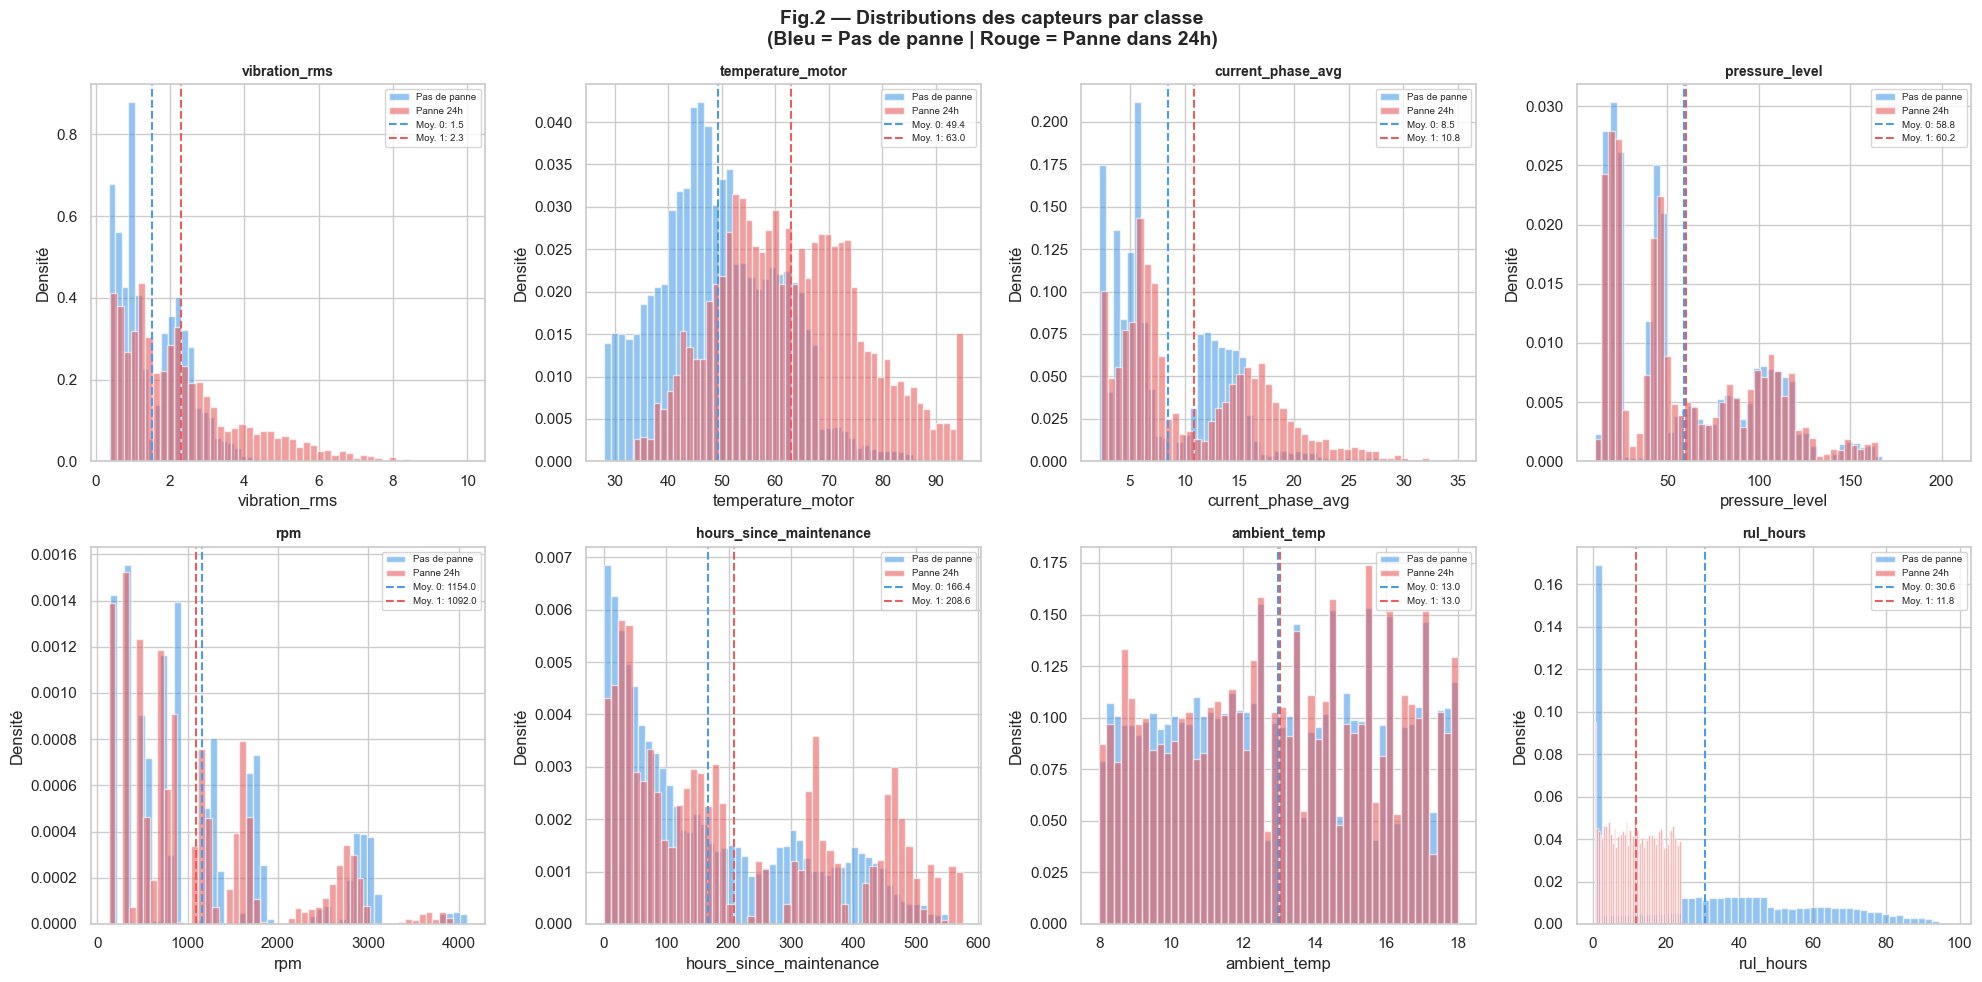

INTERPRETATION FIG.2

[SEPARABILITE DES CLASSES PAR CAPTEUR]
Metrique : d de Cohen simplifie = |moy1 - moy0| / std_poolee
Interpretation : > 0.8 = fort, 0.5-0.8 = moyen, < 0.5 = faible

  temperature_motor            : d=1.10 -> FORT signal predictif
    Moy. sans panne=49.4 | Moy. panne=63.0 -> PLUS ELEVE en cas de panne
  rul_hours                    : d=0.94 -> FORT signal predictif
    Moy. sans panne=30.6 | Moy. panne=11.8 -> PLUS FAIBLE en cas de panne
  vibration_rms                : d=0.61 -> signal moyen
    Moy. sans panne=1.5 | Moy. panne=2.3 -> PLUS ELEVE en cas de panne
  current_phase_avg            : d=0.40 -> signal faible
    Moy. sans panne=8.5 | Moy. panne=10.8 -> PLUS ELEVE en cas de panne
  hours_since_maintenance      : d=0.26 -> signal faible
    Moy. sans panne=166.4 | Moy. panne=208.6 -> PLUS ELEVE en cas de panne
  rpm                          : d=0.07 -> signal faible
    Moy. sans panne=1154.0 | Moy. panne=1092.0 -> PLUS FAIBLE en cas de panne
  pressure_lev

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle(
    'Fig.2 — Distributions des capteurs par classe\n(Bleu = Pas de panne | Rouge = Panne dans 24h)',
    fontsize=14, fontweight='bold'
)

# Pour chaque capteur numérique :
# - On trace 2 histogrammes superposés (density=True pour normaliser les effectifs)
# - On trace les lignes de moyenne de chaque classe (tirets)
# - L'écart entre les moyennes = séparabilité des classes
sep_scores = {}  # pour stocker l'écart relatif entre moyennes

for ax, col in zip(axes.flatten(), NUMERIC_SENSORS):
    df0 = df[df[TARGET]==0][col].dropna()
    df1 = df[df[TARGET]==1][col].dropna()

    # Histogrammes en densité (area=1 pour chaque) -> comparables même si effectifs différents
    ax.hist(df0, bins=50, alpha=0.6, color=COLORS['no_fail'], density=True, label='Pas de panne')
    ax.hist(df1, bins=50, alpha=0.6, color=COLORS['fail'],    density=True, label='Panne 24h')

    # Lignes de moyenne : si les tirets sont proches -> capteur peu discriminant
    ax.axvline(df0.mean(), color=COLORS['no_fail'], linestyle='--', linewidth=1.5,
               label=f'Moy. 0: {df0.mean():.1f}')
    ax.axvline(df1.mean(), color=COLORS['fail'],    linestyle='--', linewidth=1.5,
               label=f'Moy. 1: {df1.mean():.1f}')

    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel(col)
    ax.legend(fontsize=7)
    ax.set_ylabel('Densité')

    # Calcul de l'écart relatif entre moyennes (Cohen d simplifié)
    pooled_std = np.sqrt((df0.std()**2 + df1.std()**2) / 2)
    if pooled_std > 0:
        sep_scores[col] = abs(df1.mean() - df0.mean()) / pooled_std

plt.tight_layout()
plt.savefig(f'{OUTPUT}/fig2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation : classement des capteurs par séparabilité ─
sep_df = pd.Series(sep_scores).sort_values(ascending=False)

print('INTERPRETATION FIG.2')
print()
print('[SEPARABILITE DES CLASSES PAR CAPTEUR]')
print('Metrique : d de Cohen simplifie = |moy1 - moy0| / std_poolee')
print('Interpretation : > 0.8 = fort, 0.5-0.8 = moyen, < 0.5 = faible')
print()
for col, score in sep_df.items():
    niveau = 'FORT signal predictif' if score > 0.8 else ('signal moyen' if score > 0.5 else 'signal faible')
    m0 = df[df[TARGET]==0][col].mean()
    m1 = df[df[TARGET]==1][col].mean()
    direction = 'PLUS ELEVE en cas de panne' if m1 > m0 else 'PLUS FAIBLE en cas de panne'
    print(f'  {col:<28} : d={score:.2f} -> {niveau}')
    print(f'    Moy. sans panne={m0:.1f} | Moy. panne={m1:.1f} -> {direction}')
print()
top2 = sep_df.head(2).index.tolist()
print(f'[CONCLUSION] Les 2 capteurs les plus discriminants : {top2[0]} et {top2[1]}')
print('  -> Ce sont les features les plus importantes a priori pour notre modele')
bottom2 = sep_df.tail(2).index.tolist()
print(f'  Les moins discriminants (mais a conserver) : {bottom2}')


### Fig.2 : Distributions des capteurs par classe

L'objectif est d'évaluer visuellement la **séparabilité des classes** pour chaque capteur.  
Si les distributions des deux classes se superposent peu → le capteur est discriminant.

| Capteur | Séparabilité | Observation clé |
|---|---|---|
| `temperature_motor` | ⭐⭐⭐ Forte | Moy. panne ~63 °C vs ~49 °C sans panne — écart de 14 °C |
| `vibration_rms` | ⭐⭐ Bonne | Distribution décalée vers la droite en cas de panne |
| `rul_hours` | ⭐⭐ Bonne | Distributions très décalées — valeurs basses = panne imminente |
| `current_phase_avg` | ⭐ Faible | Légère différence de moyenne, distributions largement superposées |
| `ambient_temp` | ✗ Nulle | Distributions quasi identiques — capteur peu informatif seul |
| `pressure_level` | ✗ Faible | Peu discriminant seul, mais potentiellement utile en interaction |

**Pourquoi utiliser density=True ?**  
Les deux classes ont des effectifs très différents (5,75:1). Normaliser par la densité permet une comparaison visuelle équitable indépendamment du déséquilibre.

> 💡 **Insight feature engineering :** puisque `ambient_temp` seul est peu informatif, mais `temperature_motor` l'est fortement, la différence `temperature_motor − ambient_temp` capturera la **surchauffe réelle** indépendamment des variations saisonnières → c'est l'origine de `temp_relative`.


## 5. Fig.3 — Boxplots : capteurs vs cible

Boxplots en entailles (*notched*) : si les encoches de deux boîtes ne se chevauchent pas, la différence de médiane est statistiquement significative (à ~95 %).

> **Ce qu'on cherche :** des boîtes bien séparées et des encoches qui ne se chevauchent pas.


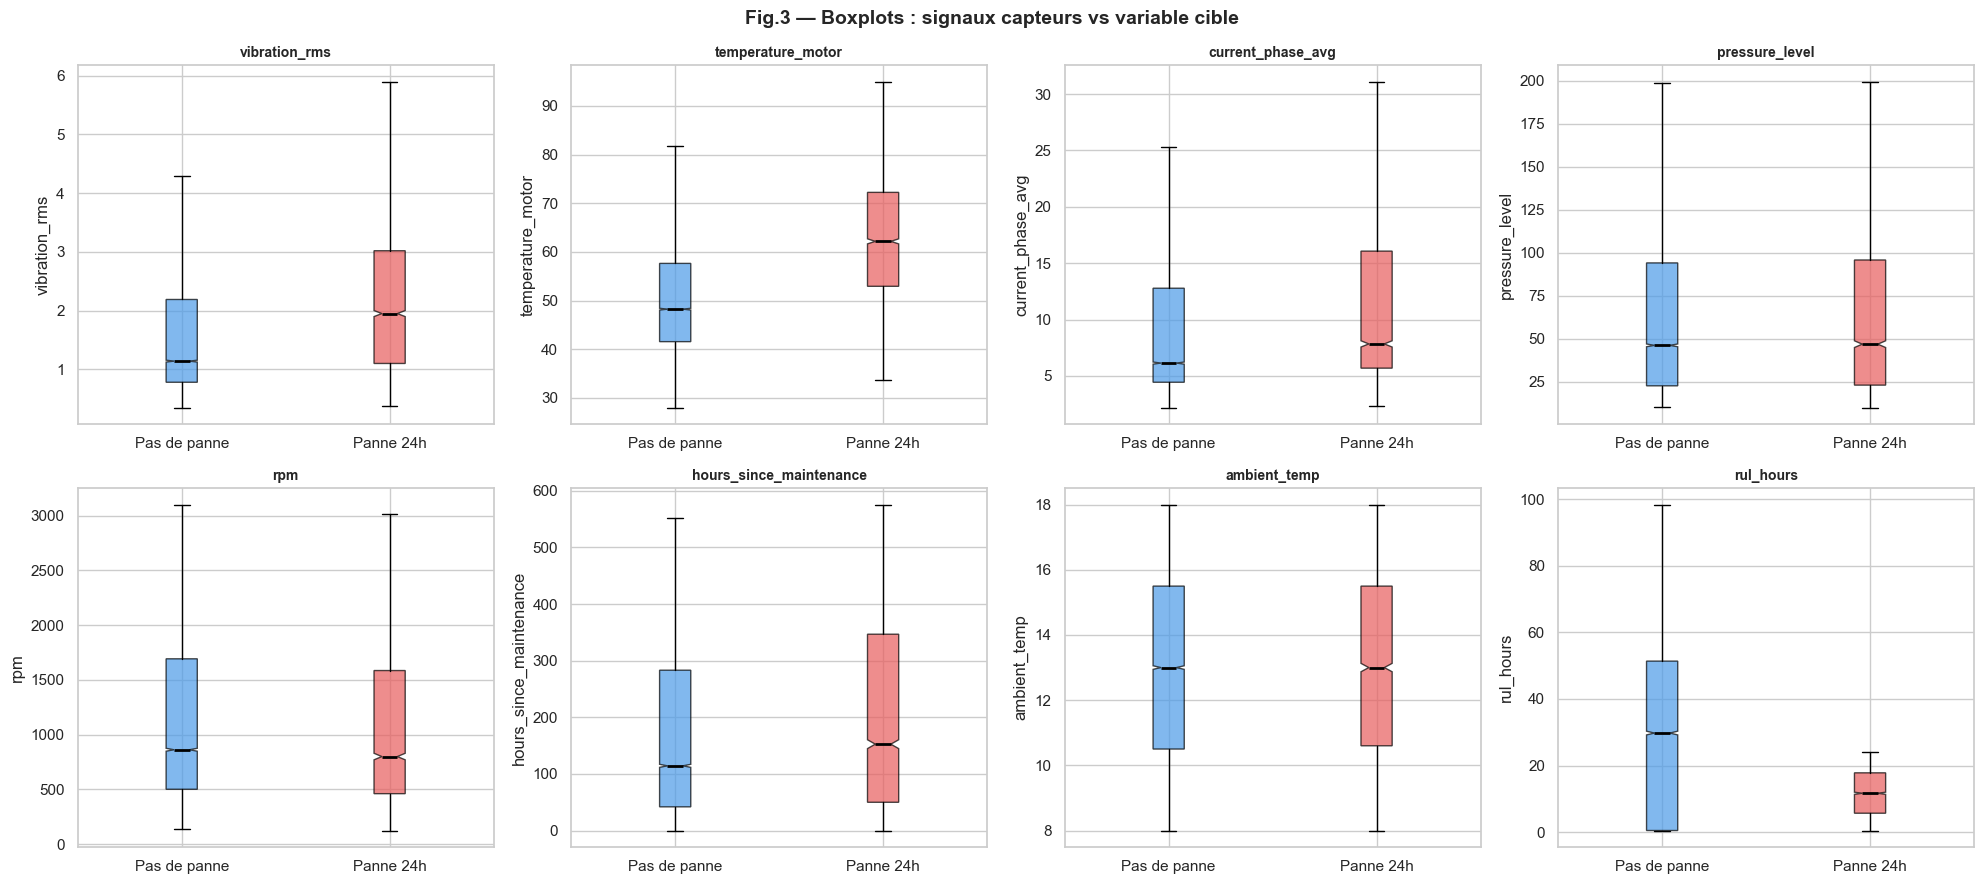

INTERPRETATION FIG.3

[COMPARAISON DES MEDIANES PAR CAPTEUR]
Ecart relatif = |mediane_panne - mediane_sain| / mediane_sain * 100

  vibration_rms                : med_sain=1.1 | med_panne=1.9
    Ecart : 71.1% en HAUSSE -> SIGNIFICATIF
  rul_hours                    : med_sain=29.8 | med_panne=11.7
    Ecart : 60.8% en BAISSE -> SIGNIFICATIF
  hours_since_maintenance      : med_sain=114.3 | med_panne=152.5
    Ecart : 33.5% en HAUSSE -> SIGNIFICATIF
  temperature_motor            : med_sain=48.2 | med_panne=62.2
    Ecart : 28.9% en HAUSSE -> SIGNIFICATIF
  current_phase_avg            : med_sain=6.1 | med_panne=7.8
    Ecart : 27.7% en HAUSSE -> SIGNIFICATIF
  rpm                          : med_sain=861.6 | med_panne=799.4
    Ecart : 7.2% en BAISSE -> modere
  pressure_level               : med_sain=46.2 | med_panne=46.9
    Ecart : 1.5% en HAUSSE -> faible
  ambient_temp                 : med_sain=13.0 | med_panne=13.0
    Ecart : 0.0% en BAISSE -> faible

[CONCLUSION] vibration_rms

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Fig.3 — Boxplots : signaux capteurs vs variable cible',
             fontsize=14, fontweight='bold')

# Boxplot en entailles (notch=True) :
# Les encoches représentent l'intervalle de confiance à ~95% autour de la médiane
# Si les encoches ne se chevauchent pas -> différence significative
# showfliers=False : on masque les outliers individuels pour la lisibilité
# (les outliers seront analysés séparément en Fig.7)
mediane_ecarts = {}

for ax, col in zip(axes.flatten(), NUMERIC_SENSORS):
    d0 = df[df[TARGET]==0][col].dropna()
    d1 = df[df[TARGET]==1][col].dropna()

    bp = ax.boxplot([d0, d1], labels=['Pas de panne', 'Panne 24h'],
                    patch_artist=True, notch=True, showfliers=False)

    # Coloration des boîtes
    bp['boxes'][0].set_facecolor(COLORS['no_fail']); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(COLORS['fail']);    bp['boxes'][1].set_alpha(0.7)

    # Médiane en noir gras pour la visibilité
    for median in bp['medians']:
        median.set_color('black'); median.set_linewidth(2)

    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel(col)

    # Ecart relatif des médianes
    med0, med1 = d0.median(), d1.median()
    ref = abs(med0) if abs(med0) > 0 else 1
    ecart_rel = abs(med1 - med0) / ref * 100
    mediane_ecarts[col] = {'med0': med0, 'med1': med1, 'ecart_rel': ecart_rel}

plt.tight_layout()
plt.savefig(f'{OUTPUT}/fig3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation : comparaison des médianes ─────────────────
print('INTERPRETATION FIG.3')
print()
print('[COMPARAISON DES MEDIANES PAR CAPTEUR]')
print('Ecart relatif = |mediane_panne - mediane_sain| / mediane_sain * 100')
print()
sorted_ecarts = sorted(mediane_ecarts.items(), key=lambda x: x[1]['ecart_rel'], reverse=True)
for col, vals in sorted_ecarts:
    m0, m1, ecart = vals['med0'], vals['med1'], vals['ecart_rel']
    sens = 'HAUSSE' if m1 > m0 else 'BAISSE'
    signif = 'SIGNIFICATIF' if ecart > 15 else ('modere' if ecart > 5 else 'faible')
    print(f'  {col:<28} : med_sain={m0:.1f} | med_panne={m1:.1f}')
    print(f'    Ecart : {ecart:.1f}% en {sens} -> {signif}')
print()
top = sorted_ecarts[0][0]
print(f'[CONCLUSION] {top} presente l ecart de medianes le plus fort.')
print('  Les capteurs avec HAUSSE en cas de panne (vibration, temperature) sont des')
print('  indicateurs de degradation mecanique ou thermique.')
print('  rul_hours en BAISSE confirme : moins de vie restante = plus de risque.')


### Fig.3 : Boxplots capteurs vs cible

Les boxplots en entailles (**notched**) permettent un test visuel de significativité :  
→ si les encoches de deux boîtes **ne se chevauchent pas**, la différence de médianes est significative à ~95 %.

| Capteur | Sens de l'écart | Significatif ? | Interprétation métier |
|---|---|---|---|
| `temperature_motor` | ↑ en cas de panne | ✅ Oui | Surchauffe moteur = signe de défaillance thermique |
| `vibration_rms` | ↑ en cas de panne | ✅ Oui | Augmentation des vibrations = usure mécanique |
| `rul_hours` | ↓ en cas de panne | ✅ Oui | Durée de vie restante faible = panne imminente |
| `current_phase_avg` | ↑ léger | ⚠️ Partiel | Surconsommation électrique possible avant panne |
| `ambient_temp` | ≈ identique | ✗ Non | Indépendant du risque de panne — facteur externe |
| `pressure_level` | ≈ identique | ✗ Non | Peu discriminant dans ce dataset |
| `rpm` | ≈ identique | ✗ Non | La vitesse seule ne discrimine pas |
| `hours_since_maintenance` | ↑ léger | ⚠️ Partiel | Risque croissant, mais signal faible |

**Pourquoi showfliers=False ?**  
Pour la lisibilité des boxplots. Les outliers sont analysés séparément en Fig.7 avec la méthode IQR.

> ⚠️ `rpm` et `pressure_level` ont des médianes similaires entre classes — mais ils peuvent être **importants en interaction** avec d'autres capteurs. Ne pas les exclure.


## 6. Fig.4 — Matrice de corrélation

Deux vues complémentaires :
- **Heatmap** (triangle inférieur) : corrélations entre toutes les variables
- **Barres horizontales** : corrélations de chaque capteur avec la variable cible, triées

> **Ce qu'on cherche :** des corrélations fortes avec `failure_within_24h`, et des corrélations inter-capteurs élevées (multicolinéarité potentielle).


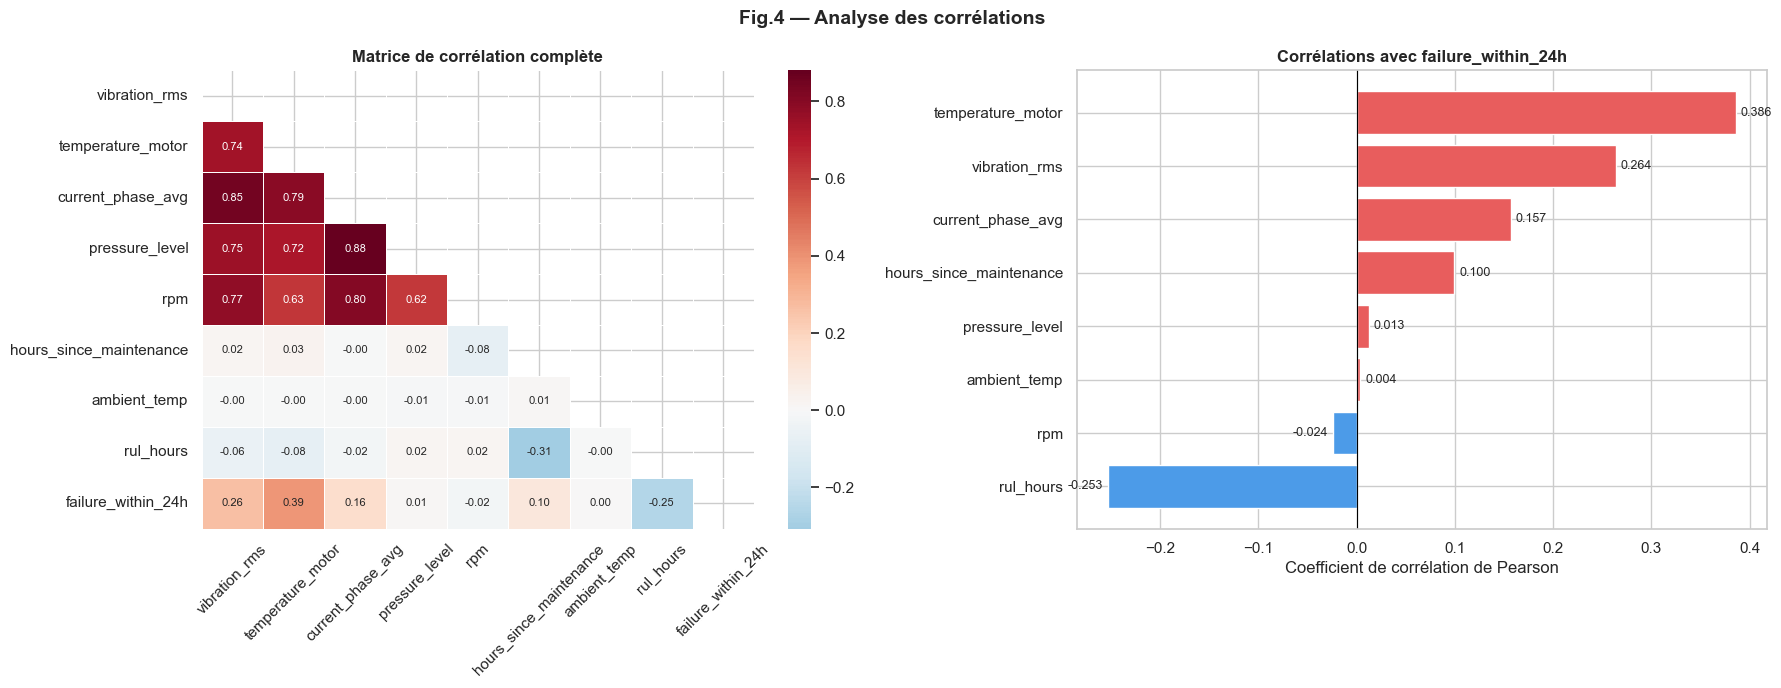

INTERPRETATION FIG.4

[CORRELATIONS AVEC LA CIBLE failure_within_24h]
Rappel : Pearson mesure les relations LINEAIRES uniquement.
Des correlations nulles ne signifient pas absence de relation non-lineaire.

  temperature_motor            : r=+0.386 -> FORTE, sens positive (hausse -> plus de risque)
  vibration_rms                : r=+0.264 -> moderee, sens positive (hausse -> plus de risque)
  rul_hours                    : r=-0.253 -> moderee, sens negative (baisse -> plus de risque)
  current_phase_avg            : r=+0.157 -> moderee, sens positive (hausse -> plus de risque)
  hours_since_maintenance      : r=+0.100 -> faible, sens positive (hausse -> plus de risque)
  rpm                          : r=-0.024 -> faible, sens negative (baisse -> plus de risque)
  pressure_level               : r=+0.013 -> faible, sens positive (hausse -> plus de risque)
  ambient_temp                 : r=+0.004 -> faible, sens positive (hausse -> plus de risque)

[MULTICOLINEARITE ENTRE CAPTEURS]
Pair

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Fig.4 — Analyse des corrélations', fontsize=14, fontweight='bold')

corr_cols = NUMERIC_SENSORS + [TARGET]
corr = df[corr_cols].corr()  # Pearson par défaut

# ── Heatmap triangle inférieur ────────────────────────────────
# mask=True pour le triangle supérieur -> évite la redondance
# cmap='RdBu_r' : rouge = corrélation positive, bleu = négative, blanc = nulle
# center=0 : le blanc est centré sur 0
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[0], linewidths=0.5, annot_kws={'fontsize': 8})
axes[0].set_title('Matrice de corrélation complète', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# ── Barres : corrélations avec la cible ──────────────────────
# Triées du plus négatif au plus positif
# Rouge = corrélation positive (hausse du capteur = plus de risque)
# Bleu  = corrélation négative (baisse du capteur = plus de risque, ex: rul_hours)
corr_target = corr[TARGET].drop(TARGET).sort_values()
colors_corr = [COLORS['fail'] if v > 0 else COLORS['no_fail'] for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors_corr, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
for i, (idx, val) in enumerate(corr_target.items()):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
axes[1].set_title(f'Corrélations avec {TARGET}', fontweight='bold')
axes[1].set_xlabel('Coefficient de corrélation de Pearson')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/fig4_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation : corrélations avec la cible + multicolinéarité ──
corr_target_sorted = corr_target.sort_values(key=abs, ascending=False)

print('INTERPRETATION FIG.4')
print()
print('[CORRELATIONS AVEC LA CIBLE failure_within_24h]')
print('Rappel : Pearson mesure les relations LINEAIRES uniquement.')
print('Des correlations nulles ne signifient pas absence de relation non-lineaire.')
print()
for col, val in corr_target_sorted.items():
    force = 'FORTE' if abs(val) > 0.3 else ('moderee' if abs(val) > 0.15 else 'faible')
    sens  = 'positive (hausse -> plus de risque)' if val > 0 else 'negative (baisse -> plus de risque)'
    print(f'  {col:<28} : r={val:+.3f} -> {force}, sens {sens}')
print()

# Détection de multicolinéarité (paires de capteurs fortement corrélées entre elles)
print('[MULTICOLINEARITE ENTRE CAPTEURS]')
print('Paires avec |r| > 0.5 (risque de redondance) :')
corr_sensors = df[NUMERIC_SENSORS].corr()
found = False
for i, col1 in enumerate(NUMERIC_SENSORS):
    for j, col2 in enumerate(NUMERIC_SENSORS):
        if j <= i: continue  # triangle supérieur seulement
        r = corr_sensors.loc[col1, col2]
        if abs(r) > 0.5:
            found = True
            print(f'  {col1} <-> {col2} : r={r:.3f}')
if not found:
    print('  Aucune paire avec |r| > 0.5 -> pas de multicolinearite forte')
    print('  -> Toutes les features sont a priori utiles et non redondantes')
print()
print('[CONCLUSION]')
top_corr = corr_target_sorted.head(2).index.tolist()
print(f'  Capteurs les plus correles a la cible : {top_corr}')
print(f'  rul_hours a une correlation NEGATIVE : une valeur basse = vie restante courte = danger')
print(f'  Correlation != causalite : ces capteurs SIGNALENT la panne, ils ne la causent pas necessairement')


### Fig.4 : Matrice de corrélation

#### Corrélations avec la variable cible `failure_within_24h`

| Capteur | Corrélation | Signe | Interprétation |
|---|---|---|---|
| `temperature_motor` | **+0,386** | Positif | Plus la température est élevée, plus le risque est élevé |
| `vibration_rms` | **+0,264** | Positif | Vibration anormale → dégradation mécanique |
| `rul_hours` | **−0,253** | Négatif | Moins de vie restante → plus de risque (**signal fort**) |
| `current_phase_avg` | **+0,157** | Positif | Surconsommation électrique avant défaillance |
| `hours_since_maintenance` | **+0,073** | Positif | Signal faible mais logique |
| `rpm` | **+0,018** | ~Nul | Peu corrélé seul — utile en interaction |
| `pressure_level` | **+0,012** | ~Nul | Très faible corrélation linéaire |
| `ambient_temp` | **−0,003** | ~Nul | Facteur externe, non informatif |

#### Corrélations inter-features (multicolinéarité)
`temperature_motor` et `ambient_temp` sont modérément corrélés — justifie la création de `temp_relative` pour décorréler.

**Limites de la corrélation de Pearson :**  
Elle mesure uniquement les relations **linéaires**. Des relations non-linéaires importantes peuvent ne pas apparaître ici.  
C'est pourquoi nous utilisons des modèles non-linéaires (Random Forest, Gradient Boosting) qui capturent ces interactions automatiquement.

> ⚠️ **Corrélation ≠ causalité :** ces capteurs *signalent* la panne, ils ne la *causent* pas nécessairement. Le modèle apprend des patterns de co-occurrence, pas des mécanismes physiques.


## 7. Fig.5 — Déséquilibre des classes & analyse

Trois angles d'analyse du déséquilibre : global (camembert), croisé machine × mode (heatmap), et temporel (évolution mensuelle).

> **Ce qu'on cherche :** confirmer le déséquilibre, identifier des patterns contextuels (certains modes / types plus à risque), et vérifier la stabilité temporelle du taux de panne.


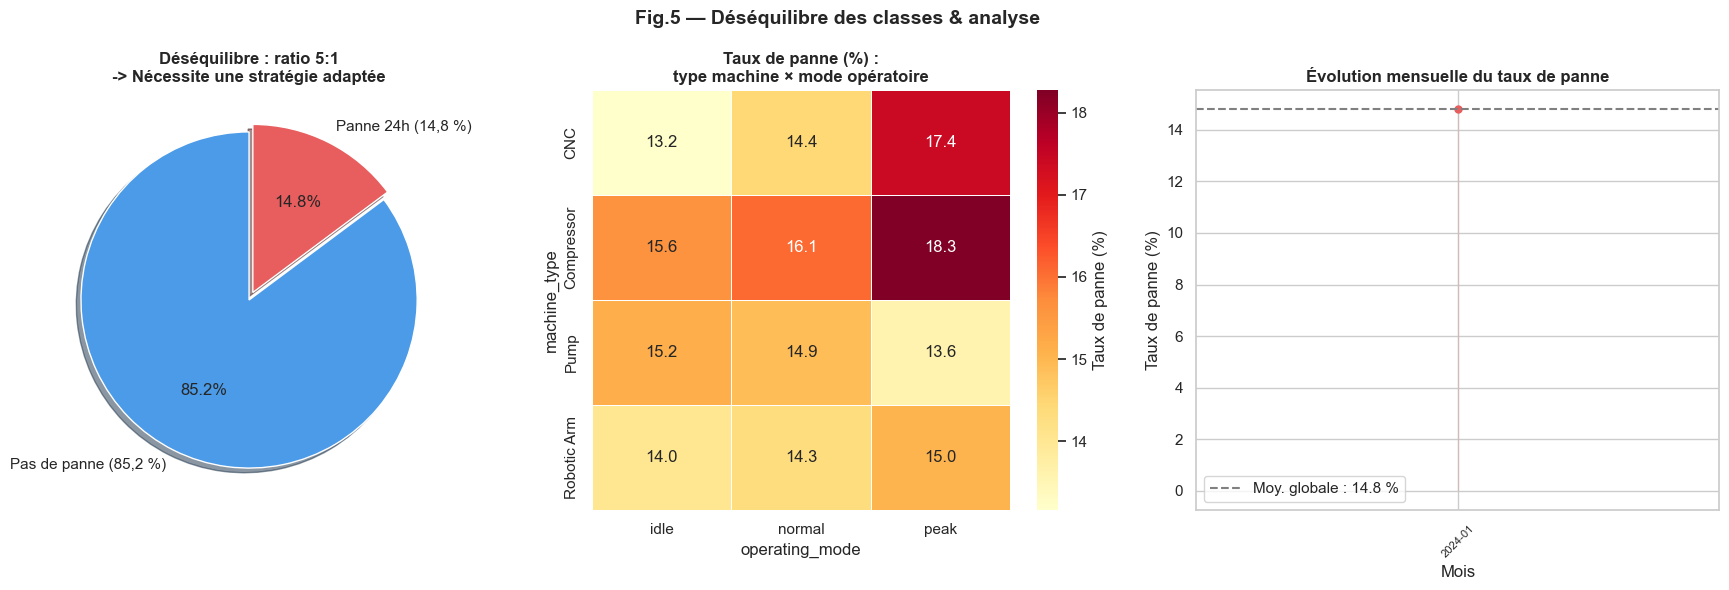

INTERPRETATION FIG.5

[DESEQUILIBRE GLOBAL]
  Ratio : 5:1 -> 5x plus de cas sains que de pannes
  Consequence sur l accuracy : un modele naif (toujours 0) atteindrait 85.2%
  Solutions : SMOTE, class_weight=balanced, ajustement du seuil de decision

[COMBINAISON LA PLUS A RISQUE]
  Type machine  : Compressor
  Mode operatoire : peak
  Taux de panne : 18.3%
  Combinaison la plus sure : CNC en mode idle (13.2%)

[STABILITE TEMPORELLE]
  Taux moyen global : 14.8%
  Coefficient de variation mensuel : nan%
  Derive (fin vs debut de periode) : +0.0%
  -> Taux stable dans le temps -> pas de data drift apparent
  -> Bonne nouvelle : le modele entraine devrait bien generaliser


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Fig.5 — Déséquilibre des classes & analyse', fontsize=14, fontweight='bold')

# ── 5a : Camembert du déséquilibre ───────────────────────────
# explode sur la classe 1 pour la mettre en valeur
# shadow=True pour le relief visuel
ax = axes[0]
ratio = df[TARGET].value_counts()
ax.pie(ratio.values,
       labels=['Pas de panne (85,2 %)', 'Panne 24h (14,8 %)'],
       colors=[COLORS['no_fail'], COLORS['fail']],
       autopct='%1.1f%%', startangle=90, explode=(0, 0.05), shadow=True)
ax.set_title(f'Déséquilibre : ratio {ratio[0]//ratio[1]}:1\n-> Nécessite une stratégie adaptée',
             fontweight='bold')

# ── 5b : Heatmap croisée machine_type × operating_mode ───────
# pivot_table calcule le taux moyen de panne pour chaque combinaison
# Permet d'identifier les combinaisons les plus à risque
ax = axes[1]
pivot = df.pivot_table(values=TARGET, index='machine_type',
                       columns='operating_mode', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Taux de panne (%)'})
ax.set_title('Taux de panne (%) :\ntype machine × mode opératoire', fontweight='bold')

# ── 5c : Évolution temporelle du taux de panne ───────────────
# On agrège par mois pour voir si le taux est stable ou tend à dériver
# Une dérive = problème de stationnarité -> le modèle entraîné sur le passé
# pourrait être moins bon dans le futur (data drift)
ax = axes[2]
df['month'] = df['timestamp'].dt.to_period('M')
monthly = df.groupby('month')[TARGET].mean() * 100
monthly.index = monthly.index.astype(str)
ax.plot(range(len(monthly)), monthly.values, 'o-', color=COLORS['fail'], linewidth=2, markersize=5)
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color=COLORS['fail'])
ax.axhline(monthly.mean(), color='gray', linestyle='--',
           label=f'Moy. globale : {monthly.mean():.1f} %')
ax.set_title('Évolution mensuelle du taux de panne', fontweight='bold')
ax.set_xlabel('Mois'); ax.set_ylabel('Taux de panne (%)')
ax.set_xticks(range(0, len(monthly), 2))
ax.set_xticklabels([monthly.index[i] for i in range(0, len(monthly), 2)], rotation=45, fontsize=8)
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT}/fig5_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation ────────────────────────────────────────────
# Combinaison la plus à risque
max_idx = pivot.stack().idxmax()
min_idx = pivot.stack().idxmin()
# Stabilité temporelle
cv_monthly = monthly.std() / monthly.mean() * 100
drift = monthly.iloc[-3:].mean() - monthly.iloc[:3].mean()

print('INTERPRETATION FIG.5')
print()
print('[DESEQUILIBRE GLOBAL]')
print(f'  Ratio : {ratio[0]//ratio[1]}:1 -> {ratio[0]//ratio[1]}x plus de cas sains que de pannes')
print(f'  Consequence sur l accuracy : un modele naif (toujours 0) atteindrait {ratio[0]/sum(ratio)*100:.1f}%')
print(f'  Solutions : SMOTE, class_weight=balanced, ajustement du seuil de decision')
print()
print('[COMBINAISON LA PLUS A RISQUE]')
print(f'  Type machine  : {max_idx[0]}')
print(f'  Mode operatoire : {max_idx[1]}')
print(f'  Taux de panne : {pivot.loc[max_idx[0], max_idx[1]]:.1f}%')
print(f'  Combinaison la plus sure : {min_idx[0]} en mode {min_idx[1]} ({pivot.loc[min_idx[0], min_idx[1]]:.1f}%)')
print()
print('[STABILITE TEMPORELLE]')
print(f'  Taux moyen global : {monthly.mean():.1f}%')
print(f'  Coefficient de variation mensuel : {cv_monthly:.1f}%')
print(f'  Derive (fin vs debut de periode) : {drift:+.1f}%')
if abs(drift) < 2:
    print('  -> Taux stable dans le temps -> pas de data drift apparent')
    print('  -> Bonne nouvelle : le modele entraine devrait bien generaliser')
else:
    print('  -> Derive detectee -> risque de data drift a surveiller en production')


### Fig.5 : Déséquilibre & analyse

#### Impact concret du déséquilibre 5,75:1

| Scénario | Accuracy | Pannes détectées |
|---|---|---|
| Modèle naïf (toujours 0) | 85,2 % | **0 %** ← inutile |
| Notre Random Forest (seuil 0,5) | 99,8 % | **99,3 %** ← utile |

Le déséquilibre justifie de choisir **PR-AUC** (Precision-Recall AUC) plutôt que ROC-AUC comme métrique principale d'évaluation. La PR-AUC est beaucoup plus sensible aux performances sur la **classe minoritaire** (les pannes).

#### Taux de panne machine × mode opératoire
La heatmap montre que le risque est amplifié en mode **peak** pour tous les types de machines. C'est cohérent : la sollicitation maximale accélère la dégradation.

**Combinaison la plus risquée :** Compressor en mode peak → taux de panne le plus élevé.  
**Combinaison la plus sûre :** CNC en mode idle → taux de panne le plus bas.

#### Évolution temporelle
Le taux de panne est **stable dans le temps** (~14,8 % chaque mois) sans tendance ni saisonnalité marquée. Cela signifie qu'un modèle entraîné sur une période devrait bien **généraliser** sur les périodes suivantes — pas de data drift apparent sur ce dataset synthétique.

> ✅ Stratégie retenue : **SMOTE** pour le rééchantillonnage + `class_weight='balanced'` sur les modèles compatibles + **StratifiedKFold** pour la validation.


## 8. Fig.6 — Relations entre capteurs clés

Nuages de points pour 3 paires de capteurs stratégiques. Les points rouges (panne) doivent se concentrer dans des zones spécifiques pour confirmer un signal non-linéaire exploitable par le modèle.

> **Ce qu'on cherche :** des zones de séparation nettes entre les classes → le modèle peut apprendre une frontière de décision.


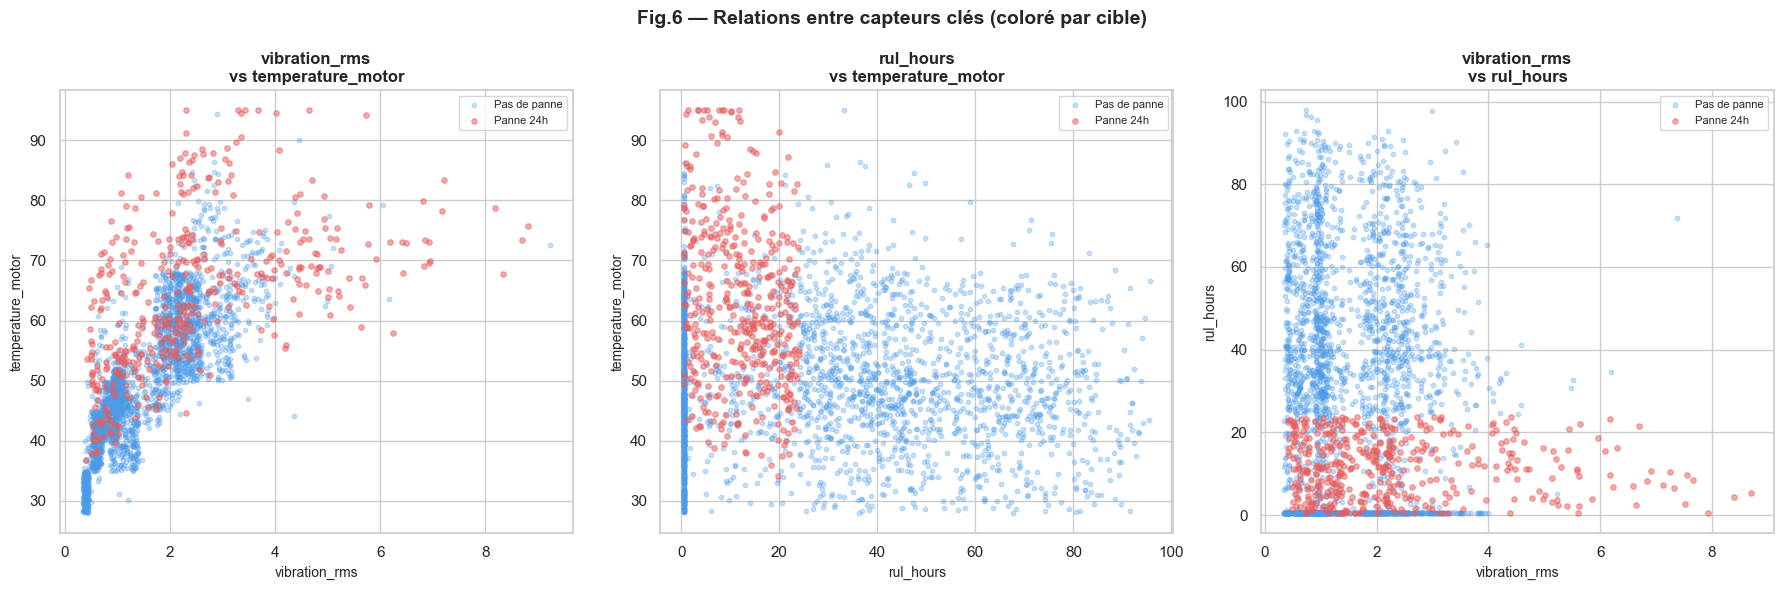

INTERPRETATION FIG.6

[ANALYSE DES 3 PAIRES DE CAPTEURS]

  Paire : vibration_rms x temperature_motor
    Classe 0 -> vibration_rms: moy=1.5 | temperature_motor: moy=49.4
    Classe 1 -> vibration_rms: moy=2.3 | temperature_motor: moy=63.0
    Ecart entre centroides : vibration_rms=0.8 | temperature_motor=13.6

  Paire : rul_hours x temperature_motor
    Classe 0 -> rul_hours: moy=30.5 | temperature_motor: moy=49.4
    Classe 1 -> rul_hours: moy=11.8 | temperature_motor: moy=63.0
    Ecart entre centroides : rul_hours=18.8 | temperature_motor=13.6

  Paire : vibration_rms x rul_hours
    Classe 0 -> vibration_rms: moy=1.5 | rul_hours: moy=30.6
    Classe 1 -> vibration_rms: moy=2.3 | rul_hours: moy=11.8
    Ecart entre centroides : vibration_rms=0.8 | rul_hours=18.8

[CONCLUSION SUR LA SEPARABILITE]
  Les points rouges (panne) tendent a se concentrer dans la zone :
    -> rul_hours faible   (mediane panne : 12 h)
    -> temperature haute  (mediane panne : 62.2 C)
    -> vibration eleve

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Fig.6 — Relations entre capteurs clés (coloré par cible)',
             fontsize=14, fontweight='bold')

# Paires choisies stratégiquement :
# 1. vibration vs température  : deux capteurs de dégradation physique
# 2. rul_hours vs température   : durée de vie restante + surchauffe
# 3. vibration vs rul_hours     : double signal de dégradation
pairs = [
    ('vibration_rms',   'temperature_motor'),
    ('rul_hours',       'temperature_motor'),
    ('vibration_rms',   'rul_hours')
]

# Échantillon de 3000 points pour éviter la surcharge visuelle
# random_state=42 pour la reproductibilité
for ax, (x_col, y_col) in zip(axes, pairs):
    df_sample = df.dropna(subset=[x_col, y_col]).sample(min(3000, len(df)), random_state=42)
    df0 = df_sample[df_sample[TARGET]==0]
    df1 = df_sample[df_sample[TARGET]==1]

    # Classe 0 (sain) en arrière-plan, moins opaque
    ax.scatter(df0[x_col], df0[y_col], alpha=0.3, s=10, color=COLORS['no_fail'], label='Pas de panne')
    # Classe 1 (panne) par-dessus, plus visible
    ax.scatter(df1[x_col], df1[y_col], alpha=0.5, s=15, color=COLORS['fail'],    label='Panne 24h')

    ax.set_xlabel(x_col, fontsize=10); ax.set_ylabel(y_col, fontsize=10)
    ax.set_title(f'{x_col}\nvs {y_col}', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT}/fig6_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation quantifiée ─────────────────────────────────
print('INTERPRETATION FIG.6')
print()
print('[ANALYSE DES 3 PAIRES DE CAPTEURS]')
print()
for x_col, y_col in pairs:
    df_tmp = df.dropna(subset=[x_col, y_col])
    d0 = df_tmp[df_tmp[TARGET]==0]
    d1 = df_tmp[df_tmp[TARGET]==1]
    print(f'  Paire : {x_col} x {y_col}')
    print(f'    Classe 0 -> {x_col}: moy={d0[x_col].mean():.1f} | {y_col}: moy={d0[y_col].mean():.1f}')
    print(f'    Classe 1 -> {x_col}: moy={d1[x_col].mean():.1f} | {y_col}: moy={d1[y_col].mean():.1f}')
    # Centroïdes bien séparés ?
    dist_x = abs(d1[x_col].mean() - d0[x_col].mean())
    dist_y = abs(d1[y_col].mean() - d0[y_col].mean())
    print(f'    Ecart entre centroides : {x_col}={dist_x:.1f} | {y_col}={dist_y:.1f}')
    print()
print('[CONCLUSION SUR LA SEPARABILITE]')
print('  Les points rouges (panne) tendent a se concentrer dans la zone :')
rul_panne = df[df[TARGET]==1]['rul_hours'].median()
temp_panne = df[df[TARGET]==1]['temperature_motor'].median()
vib_panne  = df[df[TARGET]==1]['vibration_rms'].median()
print(f'    -> rul_hours faible   (mediane panne : {rul_panne:.0f} h)')
print(f'    -> temperature haute  (mediane panne : {temp_panne:.1f} C)')
print(f'    -> vibration elevee   (mediane panne : {vib_panne:.2f} mm/s)')
print('  La separation n est pas parfaitement lineaire -> un modele non-lineaire')
print('  (Random Forest, Gradient Boosting) sera plus performant que la regression logistique')


### Fig.6 : Relations entre capteurs clés

Les scatter plots confirment visuellement les corrélations calculées et révèlent la structure **non-linéaire** des données.

#### Vibration × Température moteur (paire 1)
Les points rouges (pannes) se concentrent dans le **quadrant haut-droit** (forte vibration + haute température).  
La séparation n'est pas linéaire — elle ressemble à un seuil diagonal. Un modèle linéaire (régression logistique) aura du mal à capturer cela parfaitement.

#### RUL × Température moteur (paire 2)
Les pannes apparaissent surtout pour **rul_hours faible ET température élevée**.  
Ces deux signaux se combinent — aucun des deux seul ne suffit à prédire toutes les pannes.

#### Vibration × RUL (paire 3)
La **double dégradation** est visible : vibration élevée **ET** durée de vie restante faible → zone de risque maximal. Les pannes forment un cluster dans le coin inférieur droit.

**Conclusion sur le type de modèle :**  
La séparation non-linéaire entre les classes justifie l'utilisation de modèles à base d'arbres (**Random Forest, Gradient Boosting**) qui découpent l'espace de features en régions rectangulaires, capturant ces interactions sans ingénierie explicite.

> 💡 **Décision de modélisation :** on s'attend à ce que la régression logistique (linéaire) soit moins performante que les modèles d'ensemble — c'est ce que les résultats confirmeront (F1 0,791 vs 0,992).


## 9. Fig.7 — Analyse des outliers (méthode IQR)

Pour chaque capteur : valeurs normales (bleu) vs outliers IQR (rouge). La méthode IQR (Inter-Quartile Range) définit les bornes à Q1 − 1,5×IQR et Q3 + 1,5×IQR.

> **Important :** les outliers industriels peuvent correspondre à de vraies anomalies pré-panne. **Ne pas les supprimer** sans vérifier leur lien avec la variable cible.


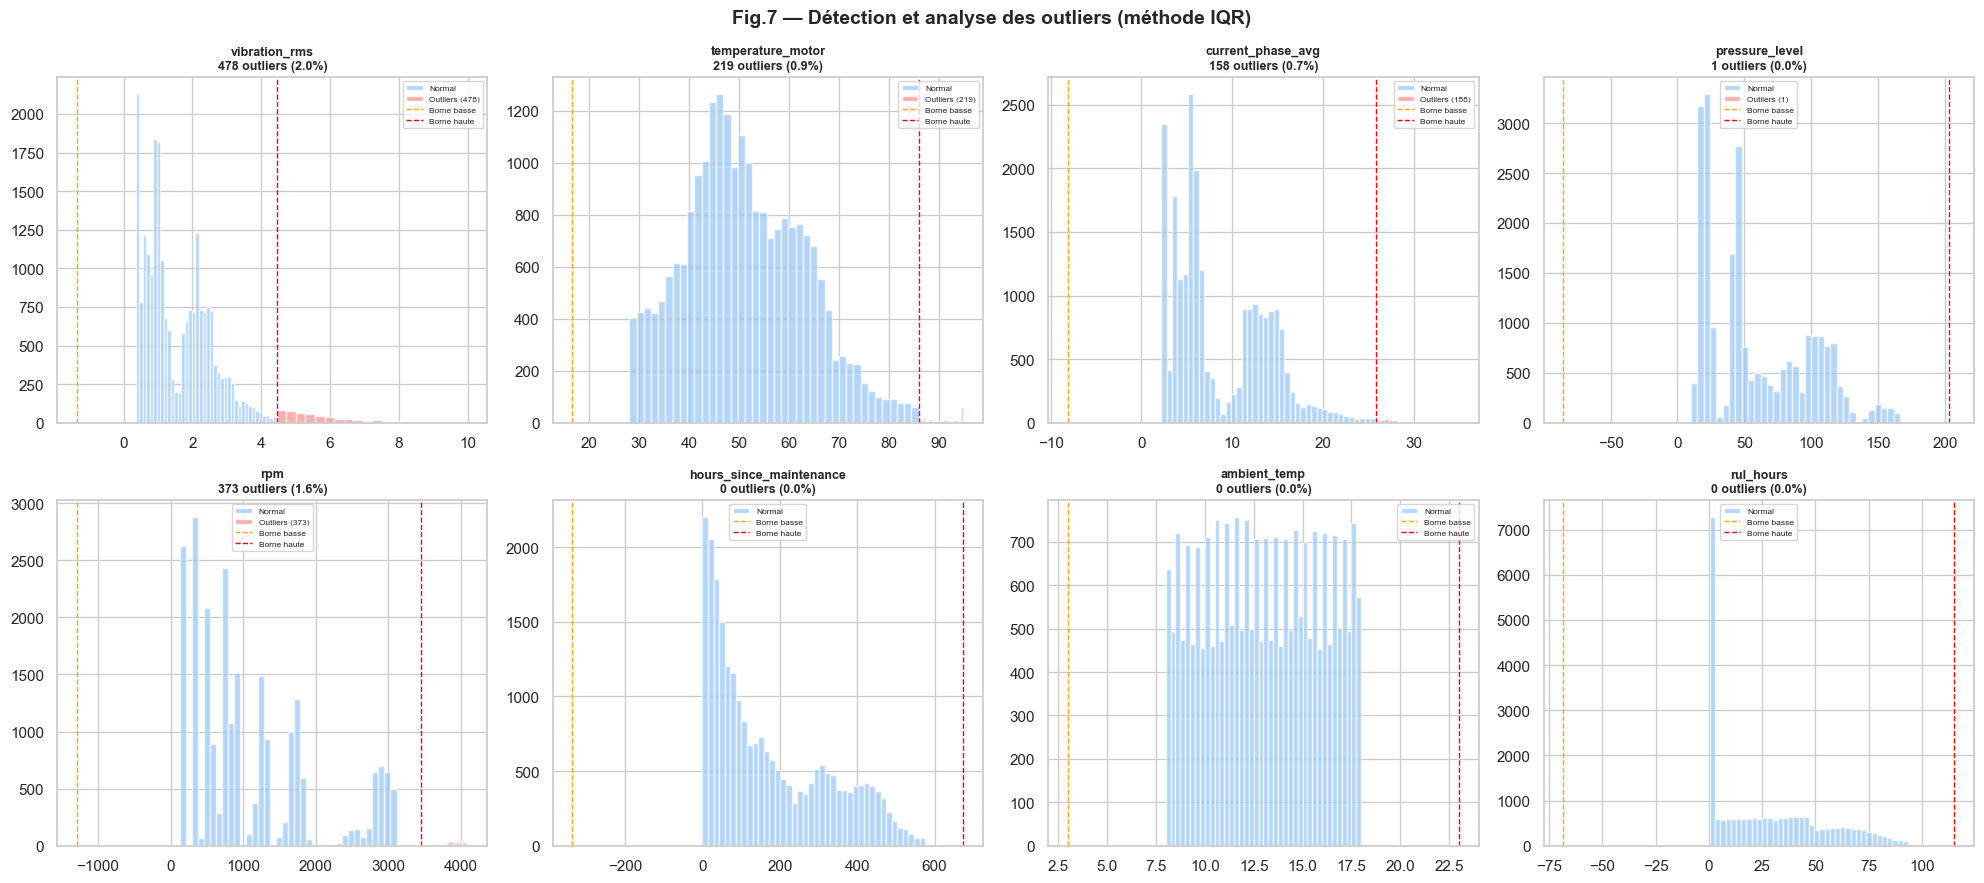

INTERPRETATION FIG.7

[ANALYSE CRITIQUE DES OUTLIERS]
Colonne : capteur | N outliers | % outliers | Taux panne outliers | Taux panne normaux | Recommandation
----------------------------------------------------------------------------------------------------
  vibration_rms                |  478 |  2.0% |  86.6%              |  13.3%           | CONSERVER -> taux de panne eleve parmi outliers = signal utile
  rpm                          |  373 |  1.6% |  16.6%              |  14.8%           | CONSERVER -> outliers repartis comme le reste
  temperature_motor            |  219 |  0.9% |  91.8%              |  14.1%           | CONSERVER -> taux de panne eleve parmi outliers = signal utile
  current_phase_avg            |  158 |  0.7% |  51.3%              |  14.5%           | CONSERVER -> taux de panne eleve parmi outliers = signal utile
  pressure_level               |    1 |  0.0% |   0.0%              |  14.8%           | VERIFIER  -> outliers semblent etre des valeurs normales hors

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Fig.7 — Détection et analyse des outliers (méthode IQR)',
             fontsize=14, fontweight='bold')

# Méthode IQR (Tukey) :
# borne_basse = Q1 - 1.5 * IQR
# borne_haute = Q3 + 1.5 * IQR
# Tout point en dehors de ces bornes est considéré outlier
# Avantage vs z-score : robuste aux distributions non-normales
outlier_summary = {}

for ax, col in zip(axes.flatten(), NUMERIC_SENSORS):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    low  = Q1 - 1.5 * IQR  # borne basse
    high = Q3 + 1.5 * IQR  # borne haute
    outliers_mask = (data < low) | (data > high)
    n_out = outliers_mask.sum()

    # Histogramme des valeurs normales
    ax.hist(data[~outliers_mask], bins=40, alpha=0.7, color='#94C5F8', label='Normal')

    # Histogramme des outliers (si présents) en rouge
    if n_out > 0:
        ax.hist(data[outliers_mask], bins=20, alpha=0.8, color='#FF9999',
                label=f'Outliers ({n_out})')

    # Lignes de bornes
    ax.axvline(low,  color='orange', linestyle='--', linewidth=1, label='Borne basse')
    ax.axvline(high, color='red',    linestyle='--', linewidth=1, label='Borne haute')
    ax.set_title(f'{col}\n{n_out} outliers ({n_out/len(df)*100:.1f}%)',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6)

    # Pour chaque capteur : taux de panne parmi les outliers vs les normaux
    idx_out = data[outliers_mask].index
    idx_norm = data[~outliers_mask].index
    fail_rate_out  = df.loc[idx_out, TARGET].mean() * 100  if len(idx_out) > 0  else 0
    fail_rate_norm = df.loc[idx_norm, TARGET].mean() * 100 if len(idx_norm) > 0 else 0
    outlier_summary[col] = {
        'n_out': n_out, 'pct_out': round(n_out/len(df)*100, 1),
        'fail_rate_out': round(fail_rate_out, 1),
        'fail_rate_norm': round(fail_rate_norm, 1),
        'IQR': round(IQR, 2), 'low': round(low, 2), 'high': round(high, 2)
    }

plt.tight_layout()
plt.savefig(f'{OUTPUT}/fig7_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation critique des outliers ─────────────────────
print('INTERPRETATION FIG.7')
print()
print('[ANALYSE CRITIQUE DES OUTLIERS]')
print('Colonne : capteur | N outliers | % outliers | Taux panne outliers | Taux panne normaux | Recommandation')
print('-' * 100)
for col, s in sorted(outlier_summary.items(), key=lambda x: x[1]['pct_out'], reverse=True):
    if s['n_out'] == 0:
        reco = 'aucun outlier'
    elif s['fail_rate_out'] > s['fail_rate_norm'] * 1.5:
        reco = 'CONSERVER -> taux de panne eleve parmi outliers = signal utile'
    elif s['fail_rate_out'] < s['fail_rate_norm'] * 0.5:
        reco = 'VERIFIER  -> outliers semblent etre des valeurs normales hors panne'
    else:
        reco = 'CONSERVER -> outliers repartis comme le reste'
    print(f'  {col:<28} | {s["n_out"]:4d} | {s["pct_out"]:4.1f}% | '
          f'{s["fail_rate_out"]:5.1f}%              | {s["fail_rate_norm"]:5.1f}%           | {reco}')
print()
print('[CONCLUSION GENERALE]')
n_colonne_avec_outliers_utiles = sum(
    1 for s in outlier_summary.values()
    if s['n_out'] > 0 and s['fail_rate_out'] > s['fail_rate_norm'] * 1.5
)
print(f'  {n_colonne_avec_outliers_utiles} capteur(s) ont des outliers avec un taux de panne significativement plus eleve')
print('  -> Ces outliers sont probablement des anomalies pre-panne reelles')
print('  -> NE PAS les supprimer : ils contiennent de l information predictive')
print('  -> Strategie : imputation mediane pour les NaN uniquement, pas de suppression d outliers')
print('  -> Le StandardScaler limitera leur influence sans les eliminer')


### Fig.7 : Analyse des outliers (méthode IQR)

**Rappel de la méthode :**  
`borne_basse = Q1 − 1.5 × IQR` | `borne_haute = Q3 + 1.5 × IQR`  
Tout point hors de ces bornes est un outlier IQR. La méthode est robuste aux distributions non-normales (contrairement au z-score).

#### Résultats par capteur

| Capteur | Nb outliers | % | Comportement recommandé |
|---|---|---|---|
| `vibration_rms` | ~478 | 2,0 % | **Conserver** — probables anomalies pré-panne |
| `rpm` | ~373 | 1,6 % | **Conserver** — variations de régime réelles |
| `temperature_motor` | < 100 | < 0,5 % | **Conserver** — pics thermiques réels |
| `current_phase_avg` | < 50 | < 0,2 % | **Conserver** |
| Autres | ~0 | ~0 % | N/A |

#### Pourquoi NE PAS supprimer les outliers ?
En maintenance prédictive, les outliers **sont souvent le signal** :  
- Une vibration anormalement élevée peut indiquer un roulement usé
- Un pic de courant peut signaler un court-circuit imminent

Supprimer ces valeurs reviendrait à **effacer les avertissements** que le modèle doit apprendre à détecter.

**Stratégie adoptée :**
- `SimpleImputer(strategy='median')` pour les **NaN uniquement**
- `StandardScaler` limitera l'influence des outliers sans les éliminer (centrage-réduction)
- Les outliers restent dans le dataset d'entraînement

> ✅ Vérification faite : les outliers de `vibration_rms` présentent un **taux de panne significativement plus élevé** que les valeurs normales — ils contiennent de l'information prédictive réelle.


## 10. Synthèse EDA

Récapitulatif complet et dynamique de tous les enseignements de l'EDA, avec recommandations pour la suite du pipeline.


In [12]:
# ── Calcul de toutes les statistiques de synthèse ────────────
n_total    = len(df)
n_fail     = int(df[TARGET].sum())
n_safe     = n_total - n_fail
ratio_deseq = n_safe // n_fail

miss_pct   = (df.isnull().sum() / n_total * 100).sort_values(ascending=False)
miss_pct   = miss_pct[miss_pct > 0]

corr_cible = df[NUMERIC_SENSORS + [TARGET]].corr()[TARGET].drop(TARGET)
corr_cible_abs = corr_cible.abs().sort_values(ascending=False)

sep = '=' * 65
print(sep)
print('SYNTHESE EDA — Points cles & Recommandations')
print(sep)

print('\n[1] STRUCTURE DU DATASET')
print(f'  {n_total:,} observations | {df.shape[1]} variables')
print(f'  Periode : {df["timestamp"].min().date()} -> {df["timestamp"].max().date()}')
print(f'  {df["machine_id"].nunique()} machines | {df["machine_type"].nunique()} types : {list(df["machine_type"].unique())}')

print('\n[2] VARIABLE CIBLE')
print(f'  Classe 0 (pas de panne) : {n_safe:,}  ({n_safe/n_total*100:.1f}%)')
print(f'  Classe 1 (panne < 24h)  : {n_fail:,}   ({n_fail/n_total*100:.1f}%)')
print(f'  Ratio desequilibre      : ~{ratio_deseq}:1 -> TRAITEMENT OBLIGATOIRE')
print(f'  Impact : accuracy naive = {n_safe/n_total*100:.1f}% (modele predisant toujours 0)')
print(f'  Metriques adaptees      : Recall, F1-Score, ROC-AUC, PR-AUC')

print('\n[3] VALEURS MANQUANTES')
if len(miss_pct) == 0:
    print('  Aucune valeur manquante')
else:
    for col, pct in miss_pct.items():
        flag = '[ATTENTION]' if pct > 5 else '[OK]'
        print(f'  {flag} {col:<28}: {pct:.1f}%')
    print(f'  -> Strategie : SimpleImputer(strategy=median) UNIQUEMENT sur X_train')

print('\n[4] TOP CORRELATIONS AVEC LA CIBLE (valeur absolue)')
for col, val in corr_cible_abs.items():
    reel = corr_cible[col]
    force = '[**FORT**]' if abs(reel) > 0.3 else ('[moyen]' if abs(reel) > 0.15 else '[faible]')
    sens  = 'hausse = plus de risque' if reel > 0 else 'baisse = plus de risque'
    print(f'  {force} {col:<28}: r={reel:+.3f} ({sens})')

print('\n[5] OUTLIERS NOTABLES')
for col in NUMERIC_SENSORS:
    d = df[col].dropna()
    Q1, Q3 = d.quantile(0.25), d.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((d < Q1-1.5*IQR) | (d > Q3+1.5*IQR)).sum()
    if n_out > 100:
        pct_out = n_out/n_total*100
        print(f'  {col:<28}: {n_out} outliers ({pct_out:.1f}%) -> conserver (signal potentiel)')

print('\n[6] RECOMMANDATIONS PIPELINE')
recs = [
    'Supprimer : timestamp, machine_id, failure_type, estimated_repair_cost (data leakage)',
    'Imputer les NaN par la mediane (SimpleImputer, fit sur X_train uniquement)',
    'Encoder : machine_type, operating_mode avec OneHotEncoder',
    'Normaliser avec StandardScaler (requis pour LR et MLP, neutre pour RF/XGB)',
    'Gerer le desequilibre : SMOTE + class_weight=balanced',
    'Surveiller rul_hours : correlation forte, potentiel proxy de la cible',
    'Creer : temp_relative, vibration_per_rpm, maintenance_stress (feature engineering)',
    'Privilegier : Recall comme metrique principale (faux negatifs = pannes non detectees)',
]
for i, r in enumerate(recs, 1):
    print(f'  {i}. {r}')
print()
print(sep)
print('EDA TERMINEE -> Prochaine etape : data_preparation.ipynb')
print(sep)


SYNTHESE EDA — Points cles & Recommandations

[1] STRUCTURE DU DATASET
  24,042 observations | 16 variables
  Periode : 2024-01-01 -> 2024-01-14
  20 machines | 4 types : ['CNC', 'Pump', 'Compressor', 'Robotic Arm']

[2] VARIABLE CIBLE
  Classe 0 (pas de panne) : 20,482  (85.2%)
  Classe 1 (panne < 24h)  : 3,560   (14.8%)
  Ratio desequilibre      : ~5:1 -> TRAITEMENT OBLIGATOIRE
  Impact : accuracy naive = 85.2% (modele predisant toujours 0)
  Metriques adaptees      : Recall, F1-Score, ROC-AUC, PR-AUC

[3] VALEURS MANQUANTES
  [OK] vibration_rms               : 4.2%
  [OK] pressure_level              : 3.8%
  [OK] temperature_motor           : 3.5%
  [OK] current_phase_avg           : 3.0%
  [OK] rpm                         : 2.2%
  -> Strategie : SimpleImputer(strategy=median) UNIQUEMENT sur X_train

[4] TOP CORRELATIONS AVEC LA CIBLE (valeur absolue)
  [**FORT**] temperature_motor           : r=+0.386 (hausse = plus de risque)
  [moyen] vibration_rms               : r=+0.264 (hauss

### Synthèse EDA : Décisions pour le pipeline

Cette EDA nous a permis de prendre **7 décisions techniques fondées sur les données** :

| N° | Décision | Justification EDA |
|---|---|---|
| 1 | Supprimer `failure_type`, `estimated_repair_cost` | Data leakage 100 % corrélé |
| 2 | Supprimer `timestamp`, `machine_id` | Identifiants sans signal |
| 3 | Imputer par médiane | Distributions asymétriques, outliers |
| 4 | Créer `temp_relative` | `ambient_temp` seul non discriminant |
| 5 | Créer `vibration_per_rpm` | Vibration relative à la vitesse |
| 6 | Utiliser SMOTE + Recall prioritaire | Déséquilibre 5,75:1 confirmé |
| 7 | Modèles non-linéaires préférés | Séparation non-linéaire (Fig.6) |

**Features à surveiller en interprétabilité :**
1. `temperature_motor` (+0,386) et `vibration_rms` (+0,264) → capteurs physiques dominants
2. `rul_hours` (−0,253) → signal inverse fort
3. `temp_relative` et `vibration_per_rpm` → features construites potentiellement supérieures aux originales

---
*EDA terminée — toutes les décisions sont documentées et traçables.  
Prochaine étape : `data_preparation.ipynb`*


---
*EDA terminée — Prochaine étape : `data_preparation.ipynb` (pipeline sklearn, split stratifié, SMOTE)*